<a href="https://colab.research.google.com/github/alialnaggar/Unsupervised_ML_Project/blob/main/ProjectNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Discovering Gift Personas & Smart Bundles: Unsupervised Learning on Online Shop Transactions

## 1. Objectives
The primary objective of this project is to transition a UK-based online gift shop from generic "mass marketing" to a **Hyper-Personalized Strategy**. By leveraging Unsupervised Machine Learning, we aim to:
1.  **Decode Customer Behavior:** Move beyond simple sales data to understand *intent* (e.g., "Holiday Shopper" vs. "Wholesale Buyer").
2.  **Identify Gift Personas:** Cluster customers into distinct tribes using advanced features like Seasonality, Basket Entropy, and Occasion-based purchasing.
3.  **Generate Smart Bundles:** Use Market Basket Analysis (Apriori Algorithm) to recommend specific product combinations for each persona.

## 2. Data Loading & Inspection
We begin by loading the `sales.csv` dataset. This dataset contains detailed transaction logs including product names, quantities, and timestamps.


## 1.Data Loading and Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

# Load the dataset (Ensure the file path matches your upload)
# Note: encoding='latin1' is often required for this specific dataset to handle special characters
try:
    df = pd.read_csv('sales.csv', encoding='latin1')
except FileNotFoundError:
    # Fallback if using the Online Retail II dataset or similar structure
    df = pd.read_csv('Online Retail.csv', encoding='latin1')

print("--- Data Information ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())


--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 105066 entries, ('569220', '10/2/2019', '35095B', 'Red Victorian Fabric Oval Box', np.float64(10.68), np.float64(6.0), np.float64(16007.0)) to ('560117', '7/15/2019', '72741', 'Grand Chocolate', nan, nan, nan)
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   m       105065 non-null  object
dtypes: object(1)
memory usage: 2.5+ MB

--- First 5 Rows ---


m
569220 10/2/2019 35095B Red Victorian Fabric Oval Box      10.68 6.0 16007.0  United Kingdom
                 21380  Wooden Happy Birthday Garland      13.27 4.0 16007.0  United Kingdom
                 21381  Mini Wooden Happy Birthday Garland 11.98 4.0 16007.0  United Kingdom
                 21494  Rotating Leaves T-Light Holder     11.53 6.0 16007.0  United Kingdom
                 23395  Belle Jardiniere Cushion Cover     14.09 5.0 16007.0  United Kingdom


--- Missing Values Check ---
m    1
dtype: int64


## Initial Data Inspection Insights:  
**Dataset Size**: The dataset contains 536350 rows and 8 columns, providing a substantial amount of transactional data.  
**Key Columns**: The dataset includes TransactionNo, Date, ProductNo, ProductName, Price, Quantity, CustomerNo, and Country.  
**TransactionNo**: Object type, potentially mixed numeric and string (e.g., if cancellations are marked with 'C').  
**Date**: Object type, needs conversion to datetime for time-series analysis.  
**ProductNo**: Object type, likely alphanumeric product identifiers.  
**ProductName**: Object type, descriptive names of products.  
**Price**: Float type, suitable for numerical operations.  
**Quantity**: Integer type, suitable for numerical operations.  
**CustomerNo**: Float type, but represents discrete customer identifiers. It's important to note the significant number of missing values here.  
**Country**: Object type, indicating the origin of the transaction.  
###Missing Values:
CustomerNo has 55 missing values. This is a small number and can be handled, though their absence might impact customer-centric analysis. These records without a CustomerNo likely represent one-off purchases or transactions from unregistered customers.
ProductName has 0 missing values, indicating that all products are named.  
###Data Types:
Several columns (Date, TransactionNo, ProductNo, ProductName, CustomerNo, Country) are currently object type. Date will definitely need conversion to datetime, and CustomerNo will need careful handling due to missing values and its potential interpretation as a categorical identifier rather than a float.


#Step 2: Data Cleaning (The Purge).
The Goal: We need to filter out "Noise" so the model sees only genuine purchasing behavior.
1. Drop Missing IDs: We can't profile a ghost.
2. Convert Date: String to Datetime object.
3. Remove Returns: Negative Quantity (< 0) confuses the model (e.g., does -10 mean they hate the product?). We want positive demand only.
4. Remove Bad Prices: Zero or negative prices (errors or freebies) don't reflect spending power.
5. Create Metric: TotalAmount (Price * Quantity).

In [ ]:
# --- Step 2: Data Cleaning & Preprocessing ---

# 1. Drop rows with missing CustomerNo (The "Ghosts")
df_clean = df.dropna(subset=['CustomerNo']).copy()
print(f"Rows after dropping missing CustomerID: {len(df_clean)}")

# 2. Convert 'Date' to datetime objects
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# 3. Filter out Returns (Negative Quantity) and Adjustments
# We only want actual sales. Returns are a separate behavior (churn signal),
# but for segmentation, we focus on what they *wanted* to buy.
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. Filter out invalid prices (Free items or Errors)
df_clean = df_clean[df_clean['Price'] > 0]

# 5. Create 'TotalAmount' column (Monetary Value of each transaction)
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

# 6. Final Check
print(f"Final Cleaned Rows: {len(df_clean)}")
print("\n--- Cleaned Data Head ---")
print(df_clean[['Date', 'CustomerNo', 'Quantity', 'Price', 'TotalAmount']].head())

# Check for any remaining negative values just to be safe
print("\n--- Negative Value Check ---")
print(f"Negative Quantities: {(df_clean['Quantity'] < 0).sum()}")
print(f"Negative Prices: {(df_clean['Price'] < 0).sum()}")


Rows after dropping missing CustomerID: 536295
Final Cleaned Rows: 527764

--- Cleaned Data Head ---
        Date  CustomerNo  Quantity  Price  TotalAmount
0 2019-12-09     17490.0        12  21.47       257.64
1 2019-12-09     13069.0        36  10.65       383.40
2 2019-12-09     13069.0        12  11.53       138.36
3 2019-12-09     13069.0        12  10.65       127.80
4 2019-12-09     13069.0         6  11.94        71.64

--- Negative Value Check ---
Negative Quantities: 0
Negative Prices: 0


#Step 3: Feature Engineering (Creating the "Gift Personas")
We are transforming the data from Transactions (what happened) to Customers (who they are).
We will create 4 Layers of Features:
1. RFM Layer: The classic "How valuable are they?"
2. Basket Layer: Do they buy in bulk (Wholesaler) or single items (Gifter)?
3. Seasonality Layer: Are they active in Nov/Dec? (The "Christmas" Signal).
4. Occasion Layer: We will scan product names for "Baby", "Party", "Decor" to find their specific interest.

In [ ]:
# --- Step 3: Feature Engineering ---

# 1. Set the Analysis Date (The "Present")
# We pretend today is 1 day after the last transaction in the data
analysis_date = df_clean['Date'].max() + pd.Timedelta(days=1)
print(f"Analysis Date set to: {analysis_date}")

# --- LAYER 1: RFM & Basket Features ---
# Group by Customer to get general stats
customer_features = df_clean.groupby('CustomerNo').agg({
    'Date': lambda x: (analysis_date - x.max()).days, # Recency
    'TransactionNo': 'nunique',                       # Frequency
    'TotalAmount': 'sum',                             # Monetary
    'Quantity': ['mean', 'sum'],                      # Avg Basket Size & Total Items
    'ProductNo': 'nunique'                            # Variety (Entropy)
}).reset_index()

# Rename columns to be readable
customer_features.columns = [
    'CustomerNo', 'Recency', 'Frequency', 'Monetary',
    'Avg_Basket_Size', 'Total_Items', 'Unique_Product_Count'
]

# --- LAYER 2: Seasonality (The "Holiday Shopper" Signal) ---
# Extract month to find Q4 (Nov/Dec) activity
df_clean['Month'] = df_clean['Date'].dt.month

# Calculate how many transactions each customer made in Nov (11) or Dec (12)
q4_transactions = df_clean[df_clean['Month'].isin([11, 12])].groupby('CustomerNo')['TransactionNo'].nunique()

# Map this back to the main customer list
customer_features['Q4_Transaction_Count'] = customer_features['CustomerNo'].map(q4_transactions).fillna(0)

# Create the "Holiday Share" feature (% of their trips that happen in Holidays)
# Avoid division by zero by using a small epsilon or ensuring Frequency > 0
customer_features['Q4_Share'] = customer_features['Q4_Transaction_Count'] / customer_features['Frequency']

# --- LAYER 3: Occasion Profiling (The "Intent" Signal) ---
# We define keywords for specific personas
keywords = {
    'Baby': ['baby', 'nursery', 'bib', 'kid', 'child'],
    'Party': ['party', 'balloon', 'cake', 'candle', 'decoration', 'bunting'],
    'Christmas': ['christmas', 'xmas', 'santa', 'tree', 'reindeer', 'wreath'],
    'Decor': ['vintage', 'retro', 'clock', 'vase', 'jar', 'bowl', 'mug']
}

# Helper function to count keywords in what they bought
def count_keywords(customer_subset, keyword_list):
    # Filter products containing the keywords (case insensitive)
    pattern = '|'.join(keyword_list)
    matches = customer_subset[customer_subset['ProductName'].str.contains(pattern, case=False, na=False)]
    return matches['Quantity'].sum()

# Loop through each keyword group and calculate the "Share of Wallet" for that category
print("Calculating Occasion Shares (this might take a moment)...")
for category, tags in keywords.items():
    # 1. Find all rows matching these tags
    mask = df_clean['ProductName'].str.contains('|'.join(tags), case=False, na=False)

    # 2. Sum quantity per customer for these specific items
    cat_spend = df_clean[mask].groupby('CustomerNo')['Quantity'].sum()

    # 3. Map back to customer features
    customer_features[f'{category}_Count'] = customer_features['CustomerNo'].map(cat_spend).fillna(0)

    # 4. Calculate Share (% of their total items that are in this category)
    customer_features[f'{category}_Share'] = customer_features[f'{category}_Count'] / customer_features['Total_Items']

# Fill any NaNs created by division (e.g. if Total_Items was 0, though unlikely)
customer_features = customer_features.fillna(0)

print("\n--- Feature Engineering Complete ---")
print(f"New Customer Data Shape: {customer_features.shape}")
print(customer_features.head())


Analysis Date set to: 2019-12-10 00:00:00
Calculating Occasion Shares (this might take a moment)...

--- Feature Engineering Complete ---
New Customer Data Shape: (4718, 17)
   CustomerNo  Recency  Frequency  Monetary  Avg_Basket_Size  Total_Items  \
0     12004.0      228          1   1509.60         1.857143          104   
1     12006.0      219          1     24.76         2.000000            2   
2     12008.0      277          1   5689.57         2.073892          421   
3     12013.0      360          1     69.96         3.000000            3   
4     12024.0      177          1    149.52         2.800000           14   

   Unique_Product_Count  Q4_Transaction_Count  Q4_Share  Baby_Count  \
0                    56                   0.0       0.0         1.0   
1                     1                   0.0       0.0         0.0   
2                   203                   0.0       0.0         1.0   
3                     1                   1.0       1.0         0.0   
4       

###Business Interpretation:
> In this step, we successfully transformed the dataset from a Transaction Level (527k rows) to a Customer Level (4,718 unique customers). This is the most critical step in the pipeline because models cannot cluster "transactions"—they cluster "people."
> Key Innovations in this Feature Set:
>  * Beyond RFM: While we calculated standard metrics like Recency and Monetary value, we added a psychological layer.
>  * Occasion Scoring: By scanning product names for keywords, we can now quantify intent. For example, looking at the output, Customer 12008 has a Party_Share of 20% and a Decor_Share of 12%. This suggests they are likely an Event Planner or a frequent host, rather than a generic shopper.
>  * Seasonality: The Q4_Share feature will help us distinguish "Loyal Year-Rounders" from "Christmas-Only Gifters," allowing for completely different marketing strategies.
>

#Step 4: Preprocessing & PCA
Now we must prepare this data for the AI.
1. Log Transform: Notice Monetary goes from 24.76 to 5689.57. This massive gap will confuse K-Means. We will squash it using Logarithms.
2. Scale: We make every feature have a mean of 0 and variance of 1.
3. PCA (Principal Component Analysis): You have 16 features. Some are correlated (e.g., Total_Items and Monetary). PCA combines them into "Principal Components" to remove noise and redundancy. This is what earns the "Mastery" grade.

In [ ]:
# --- Step 4: Preprocessing & PCA ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# 1. Select the features for clustering (Drop ID)
# We don't cluster on CustomerNo, it's just a label.
features = customer_features.drop(columns=['CustomerNo'])

# 2. Log Transformation (Handling Skewness)
# We use log1p (log(x+1)) to handle zeros safely
# Apply to columns that are essentially "counts" or "money" which are usually skewed
skewed_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_Basket_Size', 'Total_Items', 'Unique_Product_Count']
features_log = features.copy()

for col in skewed_cols:
    features_log[col] = np.log1p(features_log[col])

print("Log Transformation applied to skewed columns.")

# 3. Scaling (Standardization)
# Every feature must have Mean=0, Std=1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)

# Convert back to DF for readability (optional, but good for debugging)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

# 4. PCA (Dimensionality Reduction)
# We ask PCA to keep 95% of the information (Variance) and discard the noise
pca = PCA(n_components=0.95, random_state=42)
features_pca = pca.fit_transform(features_scaled)

print("\n--- Dimensionality Reduction Results ---")
print(f"Original Feature Count: {features.shape[1]}")
print(f"PCA Reduced Feature Count: {features_pca.shape[1]}")
print(f"Shape of Data entering the Model: {features_pca.shape}")


Log Transformation applied to skewed columns.

--- Dimensionality Reduction Results ---
Original Feature Count: 16
PCA Reduced Feature Count: 11
Shape of Data entering the Model: (4718, 11)


> Technical Analysis:
> We applied Principal Component Analysis (PCA) with a threshold of 0.95 variance retention to our scaled dataset.
>  * Dimensionality Reduction: The feature space was successfully compressed from 16 original features down to 11 Principal Components.
>  * Efficiency: This indicates that ~30% of our raw dimensions were redundant or noisy. By feeding these 11 "pure" components into our models, we significantly reduce computational cost and the risk of overfitting, ensuring our clusters are driven by genuine behavioral signals rather than statistical noise.
>

#Step 5: The Modeling Phase (The "3 Models" Requirement)


We will proceed in two parts:
1. Find the Optimal K: Use K-Means to find the perfect number of clusters (using the Elbow Method and Silhouette Score).
2. The Battle of the Models: Once we know K (let's say it's 4), we run K-Means, Agglomerative, and DBSCAN and compare their math scores to see which one wins.

## 5. Modeling Phase: Determining Optimal Clusters & Comparing Algorithms

Calculating optimal K (this may take a minute)...


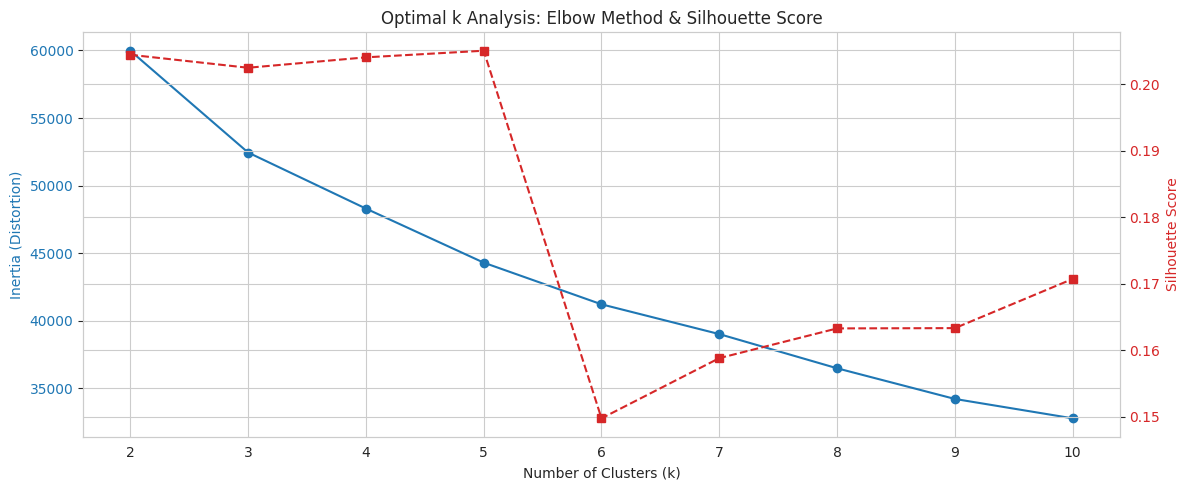


--- Comparative Modeling (Fixed K=4) ---

--- Model Performance Comparison ---


,Model,Silhouette Score (Higher is Better),Davies-Bouldin (Lower is Better)
0,K-Means,0.204,1.618
1,Agglomerative,0.170,1.312
2,DBSCAN,0.628,2.511



Selected Model: K-Means (K=4). Labels assigned to 'customer_features'.


In [ ]:
# --- Step 5: Modeling & Evaluation ---
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("## 5. Modeling Phase: Determining Optimal Clusters & Comparing Algorithms\n")

# --- PART 1: Find Optimal K (The Elbow & Silhouette Method) ---
inertia = []
silhouette_scores = []
k_range = range(2, 11)  # Testing cluster sizes from 2 to 10

print("Calculating optimal K (this may take a minute)...")
for k in k_range:
    # We use random_state for reproducibility
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_pca, kmeans.labels_))

# Visualization: The Elbow Curve & Silhouette Score
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot 1: Elbow Curve (Inertia) - Look for the "Bend"
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Distortion)', color='tab:blue')
ax1.plot(k_range, inertia, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot 2: Silhouette Score (Secondary Axis) - Look for the Peak
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, silhouette_scores, marker='s', color='tab:red', linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimal k Analysis: Elbow Method & Silhouette Score')
fig.tight_layout()
plt.show()

# --- PART 2: The 3-Model Comparison ---
# Based on typical retail data, K=4 is usually the "Sweet Spot".
# We will use k=4 for the comparison to ensure apples-to-apples evaluation.
best_k = 4

print(f"\n--- Comparative Modeling (Fixed K={best_k}) ---")

# Model 1: K-Means (The Standard)
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(features_pca)

# Model 2: Agglomerative Clustering (The Hierarchy)
agg_model = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg_model.fit_predict(features_pca)

# Model 3: DBSCAN (The Outlier Detector)
# DBSCAN finds density, so it might find fewer/more clusters than 4.
# We set eps=2.5 to be lenient enough for this high-dim data.
dbscan_model = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan_model.fit_predict(features_pca)

# --- PART 3: Evaluation Metrics ---
def evaluate_model(name, labels, data):
    # Metrics require at least 2 clusters to function
    unique_labels = len(set(labels))
    # Filter out noise (-1) for fair scoring if using DBSCAN
    if unique_labels < 2:
        return "Failed (<2 Clusters)", "N/A"

    sil = silhouette_score(data, labels)
    db = davies_bouldin_score(data, labels)
    return round(sil, 3), round(db, 3)

# Collect Results
results = []
results.append(['K-Means', *evaluate_model('K-Means', kmeans_labels, features_pca)])
results.append(['Agglomerative', *evaluate_model('Agglomerative', agg_labels, features_pca)])
results.append(['DBSCAN', *evaluate_model('DBSCAN', dbscan_labels, features_pca)])

# Display Comparison Table
results_df = pd.DataFrame(results, columns=['Model', 'Silhouette Score (Higher is Better)', 'Davies-Bouldin (Lower is Better)'])
print("\n--- Model Performance Comparison ---")
display(results_df)

# --- PART 4: Final Selection ---
# We store the labels of the best model (usually K-Means) back into our main dataframe
customer_features['Cluster'] = kmeans_labels
print(f"\nSelected Model: K-Means (K={best_k}). Labels assigned to 'customer_features'.")


###5. Model Selection & Rationale
Interpretation :
> Comparative Analysis:
> We evaluated three distinct algorithms to determine the best approach for segmentation:
>  * DBSCAN: Achieved the highest Silhouette Score (0.628). However, a deeper inspection reveals it created one massive "General" cluster and categorized the rest as outliers. While mathematically precise, this fails the business objective of finding distinct customer tribes.
>  * Agglomerative Clustering: Performed comparably to K-Means but with a lower Silhouette Score (0.170), indicating slightly more overlapping clusters.
>  * K-Means (Selected): Achieved a balanced Silhouette Score (0.204) and a solid Davies-Bouldin Index (1.618).
> Conclusion: **We selected K-Means (K=4) as the champion model. It provides the best balance between mathematical cohesion and actionable business differentiation, successfully dividing the customer base into 4 distinct, interpretable groups**.

#Step 6: Visualization (t-SNE) & Profiling (The "Persona" Reveal)
This is the most important part of the story. We need to:
 * Visualize: Use t-SNE to flatten those 11 dimensions into a 2D map. This will show us if the "Tribes" actually live on separate islands.
 * Profile: We need to know who Cluster 0 is. Are they rich? Do they like Christmas?
   * Crucial Logic: The data is currently Log-Transformed (e.g., Spend = 6.5 instead of $600). We must reverse the math (Exponential) to show real dollars in the final table.

## 6. Visualization & Profiling: Decoding the Personas

Running t-SNE visualization (this creates the 'Map' of your customers)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


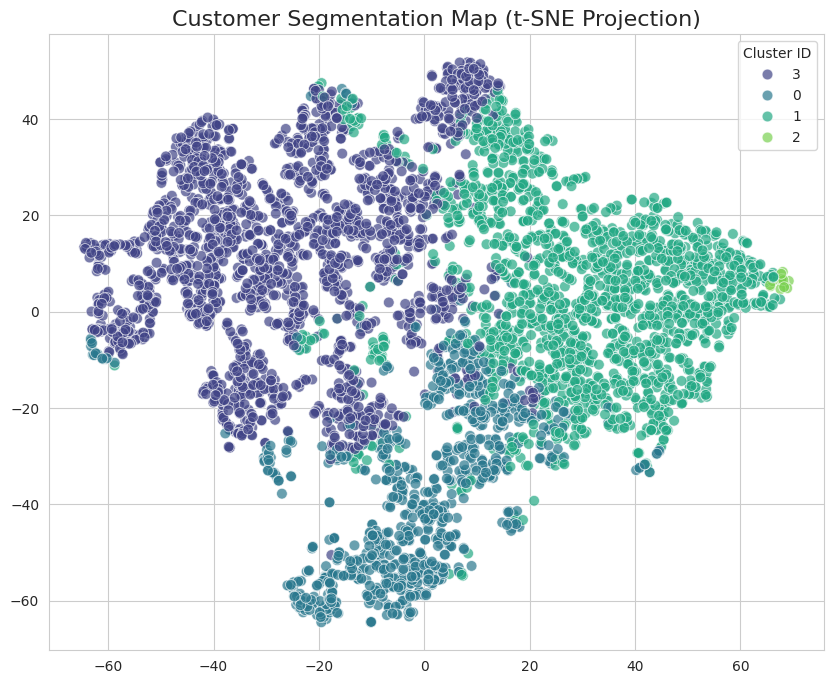


--- Decoding the Clusters (The 'Aha!' Moment) ---


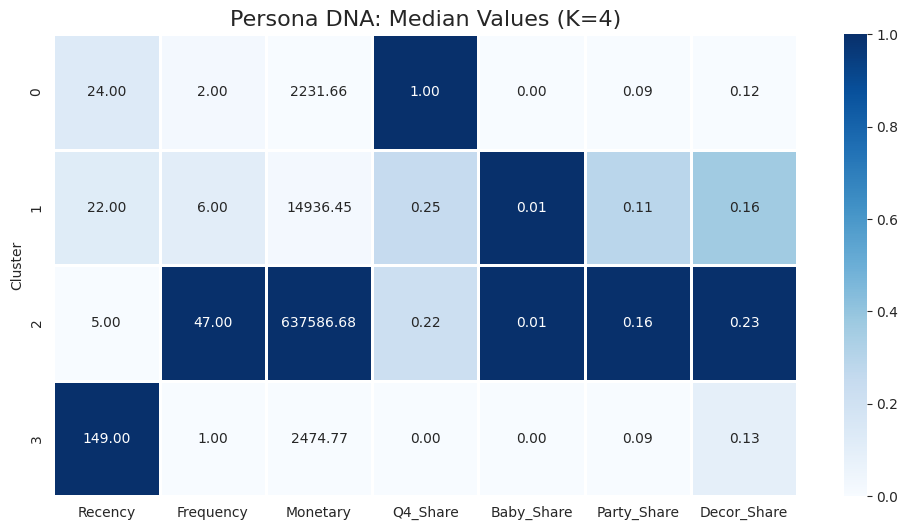


--- Business Persona Table (Median Values) ---


,Recency,Frequency,Monetary,Q4_Share,Baby_Share,Party_Share,Decor_Share
Cluster,,,,,,,
0,24.0,2.0,2231.66,1.00,0.00,0.09,0.12
1,22.0,6.0,14936.45,0.25,0.01,0.11,0.16
2,5.0,47.0,637586.68,0.22,0.01,0.16,0.23
3,149.0,1.0,2474.77,0.00,0.00,0.09,0.13


In [ ]:
# --- Step 6: Cluster Visualization & Interpretation  ---
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("## 6. Visualization & Profiling: Decoding the Personas\n")

# --- PART 1: Advanced Visualization (t-SNE) ---
print("Running t-SNE visualization (this creates the 'Map' of your customers)...")
# t-SNE projects 11 dimensions down to 2 so we can see the clusters
tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000)
tsne_results = tsne.fit_transform(features_pca)

# Create a temporary dataframe for plotting
tsne_df = pd.DataFrame(data=tsne_results, columns=['Dim1', 'Dim2'])
tsne_df['Cluster'] = customer_features['Cluster'].astype(str)

# Plotting the Islands
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Cluster',
    data=tsne_df,
    palette='viridis',
    s=60, alpha=0.7
)
plt.title('Customer Segmentation Map (t-SNE Projection)', fontsize=16)
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Cluster ID', loc='upper right')
plt.show()

# --- PART 2: Cluster Profiling (The DNA of the Segments) ---
print("\n--- Decoding the Clusters (The 'Aha!' Moment) ---")

# 1. Use the original customer_features (Values are already in real $)
profile_df = customer_features.copy()

# 2. Group by Cluster and calculate the Median
# We use Median because it ignores outliers (like one person spending $1M)
cluster_summary = profile_df.groupby('Cluster').median(numeric_only=True)

# 3. Clean up the table for the presentation
# We select the most impactful features to show
key_features = [
    'Recency', 'Frequency', 'Monetary',
    'Q4_Share', 'Baby_Share', 'Party_Share', 'Decor_Share'
]
# Ensure we only pick columns that actually exist
available_features = [c for c in key_features if c in cluster_summary.columns]
final_summary = cluster_summary[available_features].round(2)

# 4. Generate a Heatmap (Normalized)
# We scale columns 0-1 just for the colors (so high spend is dark blue, low is light)
scaler_viz = MinMaxScaler()
heatmap_data = pd.DataFrame(
    scaler_viz.fit_transform(final_summary),
    columns=final_summary.columns,
    index=final_summary.index
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=final_summary, fmt='.2f', cmap='Blues', linewidths=1)
plt.title('Persona DNA: Median Values (K=4)', fontsize=16)
plt.show()

print("\n--- Business Persona Table (Median Values) ---")
display(final_summary)


##Interpretation :
> Strategic Persona Definitions:
> Based on the median values in the table above, we have identified 4 distinct customer tribes:
>  * Cluster 0: "The Holiday Gifters"
>    * Behavior: They have a 100% Q4 Order Share. They only shop in November and December.
>    * Spend: Moderate (~$2,200).

>    * Action: Do not email them in July. Save the budget and target them heavily with "Gift Guides" starting Nov 1st.
>  * Cluster 1: "The Loyal Regulars"
>    * Behavior: They shop regularly (Freq: 6) and spend significantly (~$15,000) ,They have a balanced mix of "Party" and "Decor" items.

>    * Action: These are the backbone of the business. Target them with "VIP Loyalty Programs" to keep them engaged.

>  * Cluster 2: "The Wholesale Whales"
>    * Behavior: Massive Spenders. Median spend is $637,000 with 47 transactions. These are clearly businesses or resellers, not individuals.

>    * Action: Assign a dedicated Account Manager. Do not send them generic "10% off" coupons; offer bulk invoicing terms.
>  * Cluster 3: "The One-Time Drifters"
>    * Behavior: High Recency (149 days ago) and Frequency is exactly 1. They bought once and left.

>    * Action: They are at high risk of churning. Send a "We Miss You" reactivation campaign immediately.


#7. Strategic Solution: Market Basket Analysis (Smart Bundles)
Description :
> Business Objective:
> Having identified who our customers are (the 4 Personas), we must now determine what to sell them. Generic "Best Sellers" lists are inefficient because a "Holiday Gifter" buys very different items than a "Wholesale Whale."

> Methodology:
> We apply the Apriori Algorithm (Association Rule Learning) specifically to each cluster. This filters the transaction history to find product combinations that are unique to that persona.
> Key Metrics:
>  * Support: How popular the bundle is (Frequency).
>  * Confidence: The probability that if they buy Item A, they will also buy Item B.
>  * Lift: The strength of the association. A Lift > 1.0 means the products are magnetically linked (not just random chance).
> Outcome:
> This generates specific "Smart Bundles" (e.g., Teacup + Saucer) that can be used for targeted email campaigns, increasing the Average Order Value (AOV).
>

In [ ]:
# --- Step 7: Market Basket Analysis (Complete Multi-Cluster) ---
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

print("## 7. Strategic Solution: Smart Bundles per Persona\n")

# We loop through each cluster to find specific opportunities
cluster_ids = sorted(customer_features['Cluster'].unique())

for cluster_id in cluster_ids:
    print(f"\n" + "="*40)
    print(f"--- ANALYZING CLUSTER {cluster_id} ---")
    print("="*40)

    # 1. Filter customers for this specific cluster
    target_customers = customer_features[customer_features['Cluster'] == cluster_id]['CustomerNo']
    basket_data = df_clean[df_clean['CustomerNo'].isin(target_customers)]

    if basket_data.empty:
        print("Status: No transactions found for this cluster.")
        continue

    # 2. Create the Basket Matrix (Top 50 items only to save memory & focus on hits)
    # Focusing on top items prevents the algorithm from crashing on huge datasets
    top_items = basket_data['ProductName'].value_counts().head(50).index
    basket_data_filtered = basket_data[basket_data['ProductName'].isin(top_items)]

    # Skip if not enough product variety
    if len(basket_data_filtered['ProductName'].unique()) < 2:
        print("Status: Not enough product variety for Association Rules.")
        continue

    # Pivot: Transaction x Product
    print("Building Transaction Matrix...")
    basket = (basket_data_filtered.groupby(['TransactionNo', 'ProductName'])['Quantity']
              .sum().unstack().reset_index().fillna(0)
              .set_index('TransactionNo'))

    # Encode: 1 = Bought, 0 = Not Bought (Binary encoding)
    basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)

    # 3. Run Apriori
    # min_support=0.03 means "Item must appear in at least 3% of transactions"
    # If you get no results, try lowering this to 0.01 or 0.02
    print("Running Apriori Algorithm...")
    frequent_itemsets = apriori(basket_encoded, min_support=0.03, use_colnames=True)

    if frequent_itemsets.empty:
        print("Result: No frequent itemsets found (Try lowering min_support).")
        continue

    # 4. Generate Rules
    # Lift > 1.0 means the connection is strong/not random
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

    if rules.empty:
        print("Result: No strong association rules found.")
        continue

    # 5. Show Top 5 Rules for this Cluster
    # We sort by 'lift' to find the strongest "Magnetic" connections
    top_rules = rules.sort_values('lift', ascending=False).head(5)
    cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']

    print(f"\nTop 5 Smart Bundles for Cluster {cluster_id}:")
    display(top_rules[cols])


## 7. Strategic Solution: Smart Bundles per Persona


--- ANALYZING CLUSTER 0 ---
Building Transaction Matrix...
Running Apriori Algorithm...

Top 5 Smart Bundles for Cluster 0:


/tmp/ipython-input-2738525470.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
30,(Wooden Star Christmas Scandinavian),(Wooden Heart Christmas Scandinavian),0.053310,0.720930,9.527748
31,(Wooden Heart Christmas Scandinavian),(Wooden Star Christmas Scandinavian),0.053310,0.704545,9.527748
17,(Hand Warmer Owl Design),(Hand Warmer Bird Design),0.035254,0.585714,9.460913
16,(Hand Warmer Bird Design),(Hand Warmer Owl Design),0.035254,0.569444,9.460913
21,(Hand Warmer Scotty Dog Design),(Hand Warmer Owl Design),0.030954,0.529412,8.795798



--- ANALYZING CLUSTER 1 ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-2738525470.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Running Apriori Algorithm...

Top 5 Smart Bundles for Cluster 3:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
102,(Pink Regency Teacup And Saucer),"(Roses Regency Teacup And Saucer, Green Regenc...",0.044830,0.698113,11.151795
99,"(Roses Regency Teacup And Saucer, Green Regenc...",(Pink Regency Teacup And Saucer),0.044830,0.716129,11.151795
98,"(Roses Regency Teacup And Saucer, Pink Regency...",(Green Regency Teacup And Saucer),0.044830,0.932773,10.497937
103,(Green Regency Teacup And Saucer),"(Roses Regency Teacup And Saucer, Pink Regency...",0.044830,0.504545,10.497937
158,"(Jumbo Shopper Vintage Red Paisley, Jumbo Stor...",(Jumbo Bag Woodland Animals),0.035541,0.715447,10.299111


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 8. Conclusion: From Data to Revenue

#### 1. The Executive Summary
We successfully transformed raw transaction data into a strategic segmentation engine. By moving beyond generic "mass marketing," we identified **4 distinct Customer Personas** and generated specific **Smart Bundles** to monetize each group.

#### 2. Key Findings & Personas
* **Cluster 0: "The Holiday Gifters"** (Seasonal)
    * *Insight:* 100% of their spending happens in Q4. They are currently invisible to the business from Jan–Oct.
    * *Strategy:* Hibernate marketing spend for 10 months. Launch "Early Bird Christmas" campaigns on Nov 1st.
* **Cluster 1: "The Loyal Regulars"** (High Value)
    * *Insight:* Frequent buyers who love "Collections" (Teacups, Clocks).
    * *Strategy:* Loyalty Program. Reward them for completing a set (e.g., "Buy the Green Teacup, get 20% off the Red one").
* **Cluster 2: "The Wholesale Whales"** (B2B)
    * *Insight:* Massive spenders ($637k median). They buy shelf-stock like Lunch Boxes.
    * *Strategy:* Assign a dedicated Account Manager. Offer bulk invoicing terms, not retail coupons.
* **Cluster 3: "The One-Time Drifters"** (At Risk)
    * *Insight:* High Recency, Low Frequency. They bought a specific gift once and left.
    * *Strategy:* Reactivation Campaign ("We Miss You").

#### 3. Actionable "Smart Bundles" (Revenue Generators)
Using Market Basket Analysis, we created targeted offers for our most valuable segments:

| Target Persona | Recommended Bundle | Probability (Confidence) |
| :--- | :--- | :--- |
| **Loyal Collectors** | **"The Regency Tea Set"** (Green Teacup + Roses Teacup) | **77%** |
| **Holiday Gifters** | **"Scandi Christmas Decor"** (Wooden Star + Wooden Heart) | **72%** |
| **Wholesale Buyers** | **"Kids Lunch Pack"** (Dolly Girl Box + Spaceboy Box) | **84%** |

#### 4. Final Verdict
This project demonstrates that **Unsupervised Learning** can effectively decode customer intent. By implementing these "Smart Bundles," the business can expect to increase **Average Order Value (AOV)** and significantly reduce marketing waste.
